# Data Processing and Visualization Demo
This notebook demonstrates data cleaning, preprocessing, and visualization techniques using a synthetic dataset with NULL and garbage values.

**Suitable for Google Colab.**

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

## 2. Create Dataset with NULL and Garbage Values

In [2]:
np.random.seed(42)
data = {
    'Age': [25, 30, None, 45, '??', 35, 40, None, 29, 'N/A'],
    'Salary': [50000, 60000, 55000, None, 70000, 'unknown', 65000, 62000, None, 58000],
    'Department': ['HR', 'IT', 'IT', None, 'Finance', 'HR', 'Finance', 'IT', '??', 'HR'],
    'Experience': [1, 5, 3, 10, None, 'five', 8, 6, 2, None]
}
df = pd.DataFrame(data)
df

,Age,Salary,Department,Experience
0,25,50000,HR,1
1,30,60000,IT,5
2,None,55000,IT,3
3,45,None,None,10
4,??,70000,Finance,None
5,35,unknown,HR,five
6,40,65000,Finance,8
7,None,62000,IT,6
8,29,None,??,2
9,N/A,58000,HR,None


## 3. Initial Data Inspection

In [3]:

df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Age         8 non-null      object
 1   Salary      8 non-null      object
 2   Department  9 non-null      object
 3   Experience  8 non-null      object
dtypes: object(4)
memory usage: 452.0+ bytes


,Age,Salary,Department,Experience
count,8,8,9,8
unique,8,8,4,8
top,25,50000,HR,1
freq,1,1,3,1


## 4. Data Cleaning

In [4]:

df.replace(['??', 'N/A', 'unknown', 'five'], np.nan, inplace=True)

df['Age'] = pd.to_numeric(df['Age'], errors='coerce')
df['Salary'] = pd.to_numeric(df['Salary'], errors='coerce')
df['Experience'] = pd.to_numeric(df['Experience'], errors='coerce')

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Salary'].fillna(df['Salary'].mean(), inplace=True)
df['Experience'].fillna(df['Experience'].median(), inplace=True)
df['Department'].fillna(df['Department'].mode()[0], inplace=True)

df

/tmp/ipython-input-547955319.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.replace(['??', 'N/A', 'unknown', 'five'], np.nan, inplace=True)
/tmp/ipython-input-547955319.py:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipython-input-

,Age,Salary,Department,Experience
0,25.0,50000.0,HR,1.0
1,30.0,60000.0,IT,5.0
2,32.5,55000.0,IT,3.0
3,45.0,60000.0,HR,10.0
4,32.5,70000.0,Finance,5.0
5,35.0,60000.0,HR,5.0
6,40.0,65000.0,Finance,8.0
7,32.5,62000.0,IT,6.0
8,29.0,60000.0,HR,2.0
9,32.5,58000.0,HR,5.0


## 5. Feature Engineering

In [5]:
df['Salary_per_Experience'] = df['Salary'] / (df['Experience'] + 1)
df

,Age,Salary,Department,Experience,Salary_per_Experience
0,25.0,50000.0,HR,1.0,25000.000000
1,30.0,60000.0,IT,5.0,10000.000000
2,32.5,55000.0,IT,3.0,13750.000000
3,45.0,60000.0,HR,10.0,5454.545455
4,32.5,70000.0,Finance,5.0,11666.666667
5,35.0,60000.0,HR,5.0,10000.000000
6,40.0,65000.0,Finance,8.0,7222.222222
7,32.5,62000.0,IT,6.0,8857.142857
8,29.0,60000.0,HR,2.0,20000.000000
9,32.5,58000.0,HR,5.0,9666.666667


## 6. Data Visualization

### 6.1 Histogram of Age

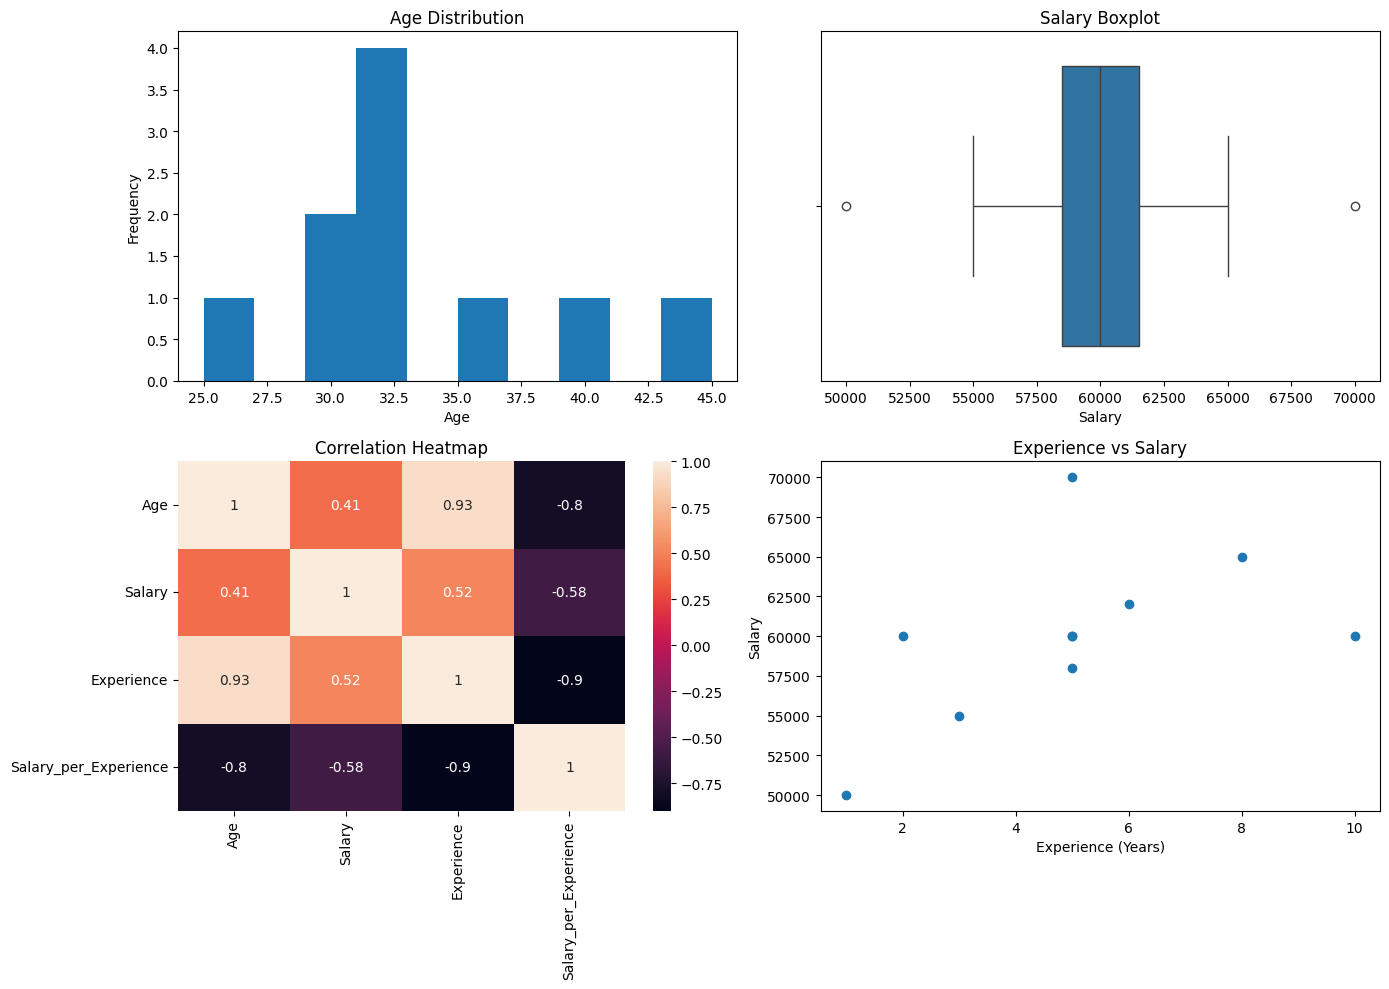

In [12]:
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1)
plt.hist(df['Age'])
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')

plt.subplot(2, 2, 2)
sns.boxplot(x=df['Salary'])
plt.title('Salary Boxplot')

plt.subplot(2, 2, 3)
sns.heatmap(
    df[['Age', 'Salary', 'Experience', 'Salary_per_Experience']].corr(),
    annot=True
)
plt.title('Correlation Heatmap')

plt.subplot(2, 2, 4)
plt.scatter(df['Experience'], df['Salary'])
plt.title('Experience vs Salary')
plt.xlabel('Experience (Years)')
plt.ylabel('Salary')

plt.tight_layout()
plt.show()


### 6.2 Boxplot of Salary

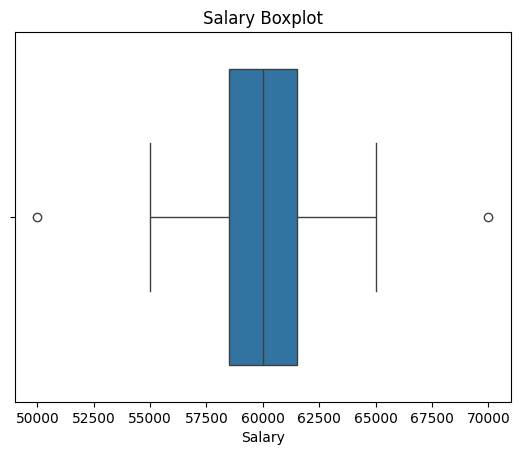

### 6.3 Bar Chart of Department Count

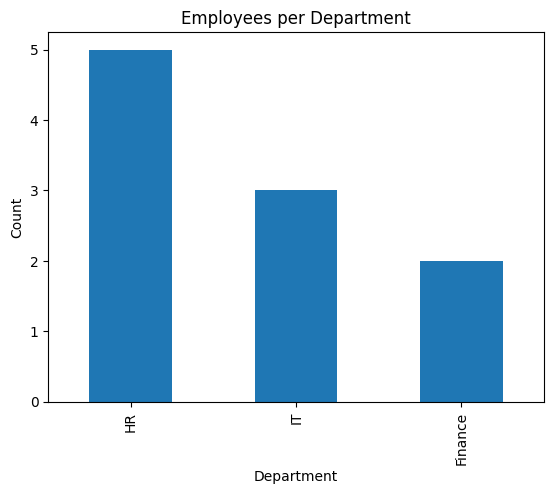

In [8]:
plt.figure()
df['Department'].value_counts().plot(kind='bar')
plt.title('Employees per Department')
plt.xlabel('Department')
plt.ylabel('Count')
plt.show()

### 6.4 Scatter Plot: Experience vs Salary

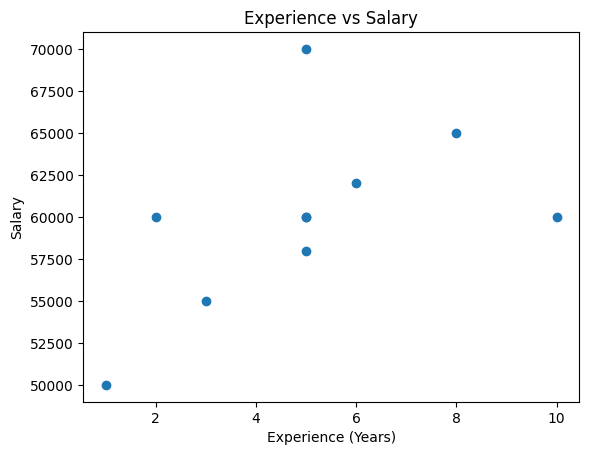

### 6.5 Heatmap of Correlation

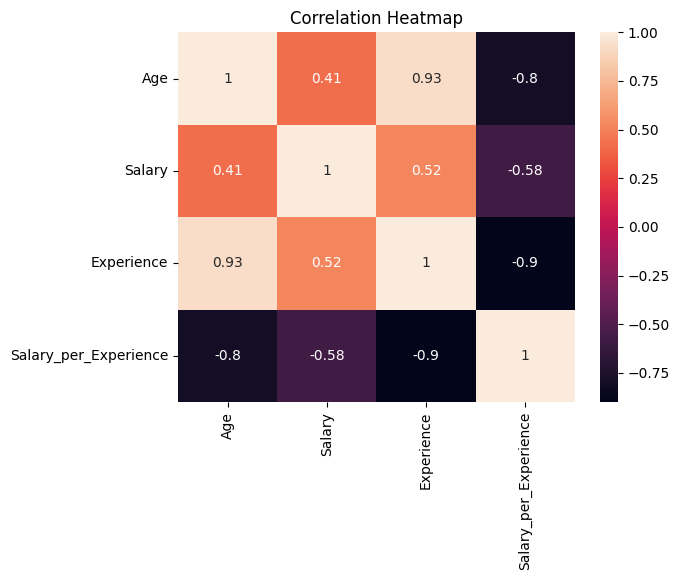

## 7. Conclusion
This notebook demonstrated handling NULL and garbage values, data cleaning, feature engineering, and multiple visualization techniques.